In [1]:
# imports and such
from pathlib import Path
from utils import load_plastchem, extract_feature_vecs, calculate_mfps
import matplotlib.pyplot as plt
from  matplotlib import rc
import numpy as np
from sklearn.manifold import TSNE
from rdkit.Chem import AllChem
import pandas as pd
from sklearn.cluster import KMeans
from pprint import pprint
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, r2_score, root_mean_squared_error, mean_absolute_error, balanced_accuracy_score, RocCurveDisplay, PrecisionRecallDisplay, make_scorer, average_precision_score
from sklearn.utils.class_weight import compute_sample_weight
from utils import load_plastchem, calculate_mfps, focal_binary_loss
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import StratifiedKFold, HalvingGridSearchCV, GridSearchCV
from xgboost import XGBClassifier
import pandas as pd
from collections import Counter
import joblib
import imblearn

In [30]:
data = np.load(Path.cwd() / "data" / "results_test.npz")
y_test, test_preds, test_probs, X_test = data["y_test"], data["test_preds"], data["test_probs"], data["X_test"]
dummy_preds, dummy_probs = data["dummy_preds"], data["dummy_probs"]
X_exploration, y_exploration = data["X_exploration"], data["y_exploration"]
nested_scores = data['nested_scores']
search = joblib.load(Path.cwd() / "data"/"search.joblib")


nr_data = np.load(Path.cwd() / "data" /"results_test_no_resample.npz")
nr_test_preds, nr_test_probs, nr_nested_scores = nr_data['nr_test_preds'], nr_data['nr_test_probs'], nr_data['nr_nested_scores']
nr_search = joblib.load(Path.cwd() / "data"/"nr_search.joblib")

In [31]:
from  matplotlib import rc
rc('font',**{'family':'sans-serif',
             'sans-serif':['Helvetica'],
             'size': 12, 
             'weight': 'normal'})
rc('text', usetex=True)

### Visualizations for results

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


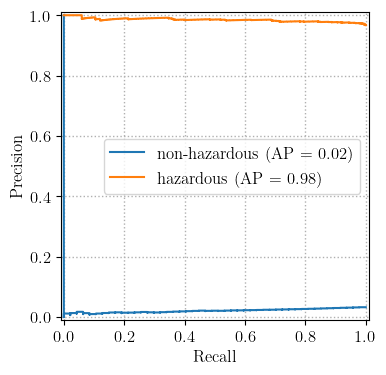

In [33]:
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
fig, ax = plt.subplots(figsize=(4,4))
# Precision Recall plot
ax.grid(zorder=0,linestyle='dotted', linewidth=1)
PrecisionRecallDisplay.from_predictions(y_test, test_probs[:, 1], pos_label=0, name="non-hazardous", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, test_probs[:, 1], pos_label=1, name="hazardous", ax=ax)
#ax.set_title("Precision recall curve for minority class")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="center right")
plt.savefig(Path.cwd() / "../report/pr_curve_min.eps", format="eps")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


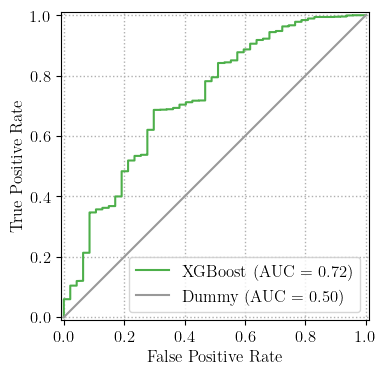

In [9]:
fig, ax = plt.subplots(figsize=(4,4))
ax.grid(zorder=0,linestyle='dotted', linewidth=1)
RocCurveDisplay.from_predictions(y_test, test_probs[:, 1], name="XGBoost", ax=ax, plot_chance_level=False, curve_kwargs={"c":"#4daf4a"})
RocCurveDisplay.from_predictions(y_test, dummy_probs[:, 1], name="Dummy", ax=ax, curve_kwargs={"c":"#999999"})
ax.legend()
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
plt.savefig(Path.cwd() / "../report/roc_auc.eps", format="eps")

In [17]:
best_model = search.best_estimator_
best_idx = search.best_index_

fold_scores = [
    search.cv_results_[f"split{i}_test_score"][best_idx]
    for i in range(5)
]

print(fold_scores)
print(np.mean(fold_scores))

[np.float64(0.5871977944295207), np.float64(0.5903082143362081), np.float64(0.676551675385268), np.float64(0.6257498333703622), np.float64(0.6005380911922968)]
0.6160691217427312


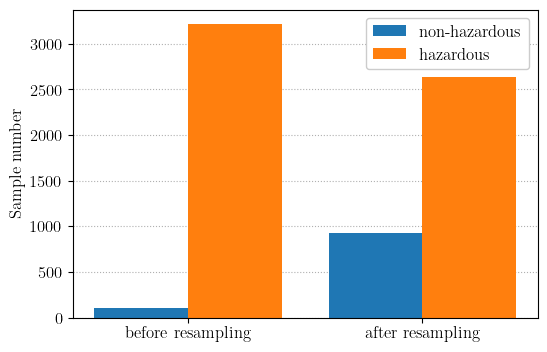

In [11]:
# SMOTE effect
before = Counter(y_exploration)
X_p = best_model.named_steps["pca"].fit_transform(X_exploration)
X_e, y_e = best_model.named_steps["smoteenn"].fit_resample(X_p, y_exploration)
after = Counter(y_e)

labels = sorted(before)
fig, ax = plt.subplots(figsize=(6,4))
x = np.arange(len(labels))
ax.grid(axis="y", zorder=0, linestyle="dotted")
ax.bar(x-0.2, [before[0], after[0]], width=0.4, label="non-hazardous", zorder=2)
ax.bar(x+0.2, [before[1], after[1]], width=0.4, label="hazardous", zorder=2)
ax.set_xticks(x, ['before resampling', 'after resampling'])
ax.legend(loc="upper right", framealpha=1)
#ax.set_xlabel("Effect of SMOTE + ENN")
ax.set_ylabel("Sample number")
#ax.set_title("Sample amount before and after resampling")
plt.savefig(Path.cwd() / "../report/smote_effect.eps", format="eps")

In [ ]:
print(before[0])
print(before[1])


print(after[0])
print(after[1])

109
3214
922
2633


In [104]:
print(np.mean(nested_scores))

0.5716247895067971


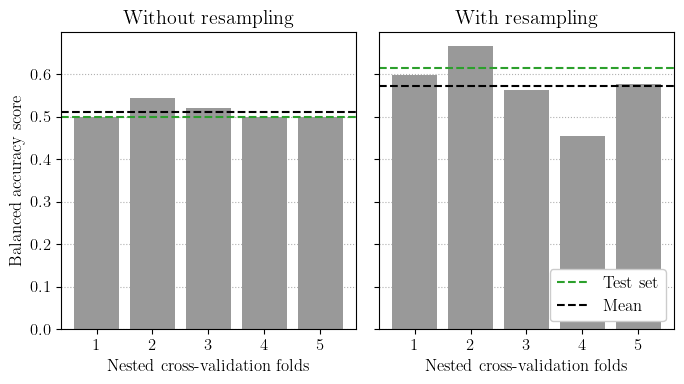

In [112]:
# CV Performance
fig, axes = plt.subplots(1, 2, figsize=(7,4), sharey=True)
ax = axes[1]
ax.grid(axis="y", zorder=0, linestyle="dotted")
ax.bar(range(5), nested_scores, color="#999999", zorder=2)
ax.axhline(balanced_accuracy_score(y_test, test_preds), color="C2", ls="--", label="Test set")
ax.axhline(np.mean(nested_scores), color="black", ls="--", label="Mean")
ax.set_xticks(range(5))
ax.set_xticklabels(range(1, 6))
ax.set_title("With resampling")
ax.set_xlabel("Nested cross-validation folds")
ax.legend(loc="lower right", framealpha=1)

axe = axes[0]
axe.grid(axis="y", zorder=0, linestyle="dotted")
axe.bar(range(5), nr_nested_scores, color="#999999", zorder=2)
axe.axhline(balanced_accuracy_score(y_test, nr_test_preds), color="C2", ls="--", label="Test set")
axe.axhline(np.mean(nr_nested_scores), color="black", ls="--", label="Mean")
axe.set_title("Without resampling")
axe.set_ylabel("Balanced accuracy score")
axe.set_xticks(range(5))
axe.set_xticklabels(range(1, 6))
axe.set_xlabel("Nested cross-validation folds")
ax.legend(loc="lower right", framealpha=1)

#ax.set_title("5-fold cross validation performance")
plt.tight_layout()
plt.savefig(Path.cwd() / ".." / "report" / "cv_performance.eps", format="eps")

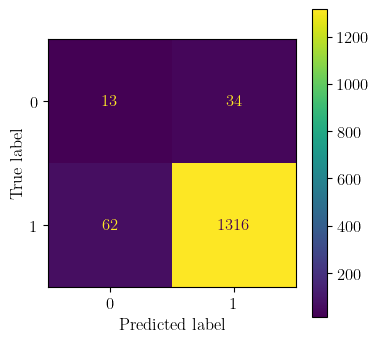

In [22]:
fig, ax = plt.subplots(figsize=(4,4))
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot(ax=ax)
plt.savefig(Path.cwd() / "../report/cm_test.eps", format="eps")
plt.show()

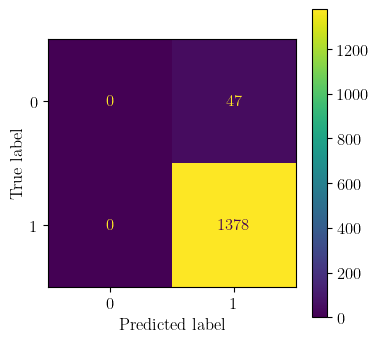

In [23]:
fig, ax = plt.subplots(figsize=(4,4))
cm = confusion_matrix(y_test, dummy_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot(ax=ax)
plt.savefig(Path.cwd() / "../report/cm_dummy.eps", format="eps")
plt.show()

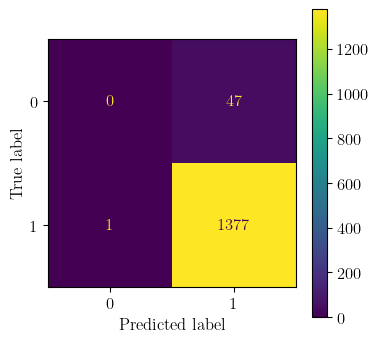

In [113]:
fig, ax = plt.subplots(figsize=(4,4))
cm = confusion_matrix(y_test, nr_test_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot(ax=ax)
plt.savefig(Path.cwd() / "../report/cm_nr_test.eps", format="eps")
plt.show()

### Values for Text

In [103]:
print(balanced_accuracy_score(y_test, test_preds))
print(classification_report(y_test, test_preds))
print(roc_auc_score(y_test, test_probs[:, 1]))

0.6158015007874502
              precision    recall  f1-score   support

         0.0       0.17      0.28      0.21        47
         1.0       0.97      0.96      0.96      1378

    accuracy                           0.93      1425
   macro avg       0.57      0.62      0.59      1425
weighted avg       0.95      0.93      0.94      1425

0.7233965352190964


In [114]:
47 + 1378

1425

In [102]:
print(search.best_params_)
print(search.best_score_)

{'clf__colsample_bylevel': 1.0, 'clf__learning_rate': 0.01, 'clf__max_depth': 7, 'clf__n_estimators': 300, 'pca__n_components': 160, 'smoteenn__sampling_strategy': 0.3}
0.6160691217427312


In [69]:
len(search.cv_results_["params"])

729

In [26]:
len(X_exploration[y_exploration==1])

3214

In [27]:
len(X_test)

1425

In [28]:
len(X_test[y_test==0.0])

47

In [29]:
pca = best_model.named_steps["pca"]
print(pca.explained_variance_ratio_.sum())

0.5921566149534921


In [115]:
print(nested_scores)

[0.59808426 0.66566521 0.56273858 0.45382508 0.57781082]
